# Multimodal Music Analysis

**Ομάδα:**
- Αθανάσιος Νικολέτας [sdi2300140]
- Αχιλλέας Πετρουλάκης [sdi2300171]


## 1.Installing dependances

In [1]:
%pip install seaborn
%pip install datasets
%pip install matplotlib
%pip install vaderSentiment
%pip install kneed
%pip install contractions
%pip install pyspellchecker
%pip install scikit-learn
%pip install pandas


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note

## 2. Loading the files and extracting data

In [2]:
import pandas as pd
import os

os.makedirs('../data/processed', exist_ok=True)

id_genres = pd.read_csv('../data/raw/id_genres.csv',sep='\t')
id_information = pd.read_csv('../data/raw/id_information.csv',sep='\t')
id_tags = pd.read_csv('../data/raw/id_tags.csv',sep='\t')


In [3]:
id_mfcc_stats = pd.read_csv('../data/raw/id_mfcc_stats.tsv.bz2',sep='\t',compression='bz2')


## Extract processed_lyrics from a tar.gz and creating processed_lyrics dictionary
for each file:

- get song_id from the filename
- read lyrics
- store to dictionary

make a dataframe using the dictionary

In [4]:
import tarfile
from pathlib import Path

processed_lyrics_dict = {}
with tarfile.open('../data/raw/processed_lyrics.tar.gz', 'r:gz') as tar:
    for member in tar.getmembers():
        if member.isfile():
            file = tar.extractfile(member)
            song_id = Path(member.name).stem
            processed_lyrics_dict[song_id] = file.read().decode('utf-8')

processed_lyrics = pd.DataFrame(
    list(processed_lyrics_dict.items()),
    columns=['id', 'lyrics']
)

processed_lyrics




,id,lyrics
0,9jbSytob9XRzwvB6,deep feel heart burn deep insid yearn know com...
1,Njp6JPM8vitbhVJU,noth hurt like pain someon love noth gain prep...
2,h48f46ZsT9h0Z5Dm,arm side heart sleev chandeli fall stand under...
3,kVtduoU5M56Amw1M,ladi ladi ladi ladi power ladi ladi ladi ladi ...
4,ZmXVK43zlqdeq6z8,end see face recogn thing must left behind pro...
...,...,...
109264,YgII1tHAaAnh14Kf,
109265,5fU9VEvtc2T1J11g,whole town line outsid tent kid think see real...
109266,76qenAf8gYlH4pfq,see store one day think may make play futur mu...
109267,9F8jQjeibAuZinEP,close right sand stretch like child night trus...


## Filtering 
each song belongs in multiple genres, therefore we explode the genre column so that each song_id, genre becomes a separate row.Note that id_genres are not clean data and each song can belong to the same genre twice.So we have to remove duplicates.We then compute the top-5 most frequent genres and select songs that belong to at least one of them.Finally, we keep only the songs that exist in all three datasets (genres, lyrics, and stats) by merging them with the id.

In [5]:
genre_exploded = id_genres.assign(
    genre = id_genres['genres'].str.split(',')
).explode('genre')

genre_exploded = genre_exploded.drop_duplicates(subset=['id', 'genre'])

genre_exploded['genre'] = genre_exploded['genre'].str.strip()

top5_list = genre_exploded['genre'].value_counts().head(5).index.tolist()


top5_data_frame = genre_exploded['genre'].value_counts().head(5).reset_index()
top5_data_frame.columns = ['genre', 'count']

print("top 5 genres with song count")
print(top5_data_frame)

chosen_ids = genre_exploded[genre_exploded['genre'].isin(top5_list)]['id'].drop_duplicates()


chosen_id_genres = id_genres[id_genres['id'].isin(chosen_ids)]

#processed_lyrics = processed_lyrics[processed_lyrics['lyrics'].str.len() >0]

full = chosen_id_genres.merge(processed_lyrics, on='id', how='inner').merge(id_mfcc_stats, on='id', how='inner')

full = full.sample(n=1000, random_state=30)
full = full.reset_index(drop=True)

print("\nfinal_dataframe with columns με στήλες: id, genre, lyrics, mfcc_stats")
print(full.head())


print("\ninfo")
full.info()

full.to_csv('../data/processed/final_dataset.csv', index=False)


top 5 genres with song count
              genre  count
0              rock  23949
1               pop  20267
2        electronic  11739
3  alternative rock   7591
4        indie rock   7353

final_dataframe with columns με στήλες: id, genre, lyrics, mfcc_stats
                 id                               genres  \
0  bDHxQM6zcdGOy8cK                           electronic   
1  XfNurIuPSNa8dQ6Q  electronic,rock,pop,electronic,rock   
2  GbByt2aAIdxsI4DH                                  pop   
3  oyR23PnOEo5tVoUG                            pop,disco   
4  cKcH5vZdSKppu74K                rock,alternative rock   

                                              lyrics    MFCC000    MFCC001  \
0                                                     21.966373  -2.961467   
1  mind someon mine someon get know hard tri conv...  23.506063 -13.045736   
2  want play game want play want stay round want ...  23.970058  -9.100973   
3  think reminisc bout day wish could fli touch s...  23.548035 -

## Text Embeddings

In [6]:
import re
import numpy as np
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)

    tokens = word_tokenize(text)

    tokens = [w for w        in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    return tokens


full['tokens'] = full['lyrics'].apply(preprocess)

from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences=full['tokens'].tolist(),
    vector_size=200, # desired no. of features/independent variables
    window=5, # context window size
    min_count=2,
    sg = 1, # 1 for skip-gram model
    hs = 0,
    negative = 10, # for negative sampling
    workers= 2, # no.of cores
    seed = 34
)

def get_embedding(tokens, model):
    vectors = [model.wv[w] for w in tokens if w in model.wv]

    if len(vectors) > 0:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)

text_embeddings = np.array([
    get_embedding(t, w2v_model)
    for t in full['tokens']
])

[nltk_data] Downloading package punkt to /home/thanos/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/thanos/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/thanos/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/thanos/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
/tmp/ipykernel_22423/3123881338.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full['tokens'] = full['lyrics'].apply(preprocess)


## Audio Ebbendings

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

mfcc_cols = [c for c in full.columns if c.startswith('MFCC') or c.startswith('cov_')]
audio_features = full[mfcc_cols].values

scaler = StandardScaler()
audio_scaled = scaler.fit_transform(audio_features)

pca = PCA(n_components=0.95)
audio_embeddings = pca.fit_transform(audio_scaled)

print(f"Original dims: {audio_features.shape[1]}")
print(f"PCA dims (95% variance): {audio_embeddings.shape[1]}")

Original dims: 104
PCA dims (95% variance): 69


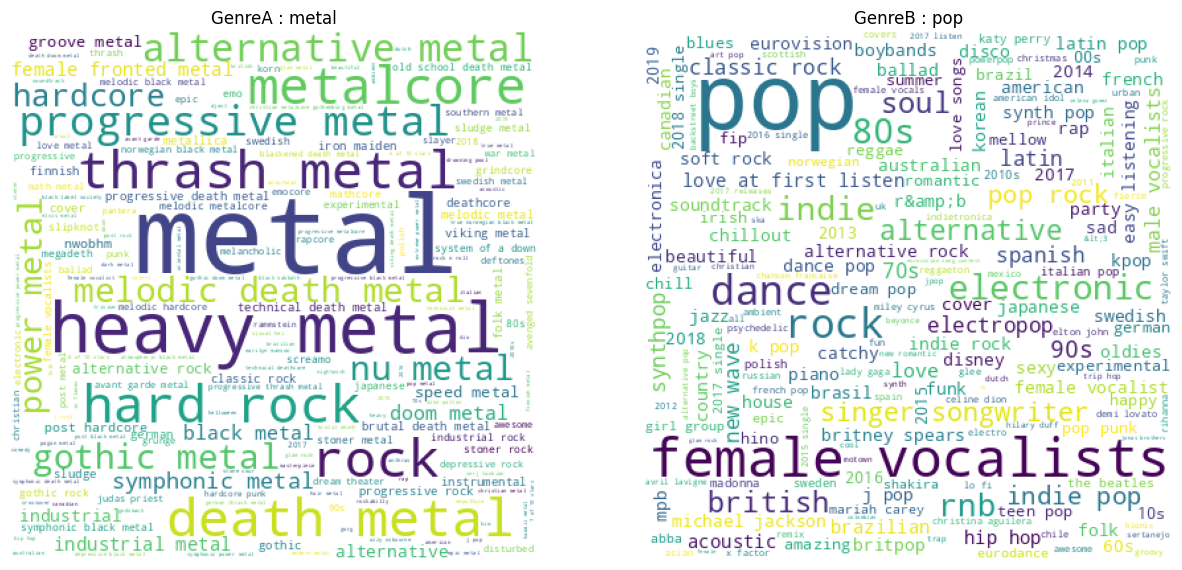

In [ ]:
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

id_tags['tags'] = id_tags['tags'].apply(
    lambda x: ','.join(dict.fromkeys(
        t.strip() for t in x.replace("-"," ").split(',')
    ))
)


genre_a, genre_b = "metal", "pop"

fig, axes = plt.subplots(1, 2, figsize=(15, 8))

for a, genre,t in zip(axes, [genre_a, genre_b],['A','B']):
    genre_ids = genre_exploded[genre_exploded['genre'].isin([genre])]['id'].unique()
    tag_freq = Counter(
        t.strip()
        for tags in id_tags[id_tags['id'].isin(genre_ids)]['tags']
        for t in tags.split(',')s
        if t.strip()
    )

    wc = WordCloud(width=400, height=400, background_color='white').generate_from_frequencies(tag_freq)
    a.imshow(wc)
    a.set_title(f'Genre{t} : {genre}')
    a.axis('off')

plt.show()

In [ ]:
fig, axes = plt.subplots(len(top5_list), 1, figsize=(10, 5 * len(top5_list)))

for ax, genre in zip(axes, top5_list):
    genre_ids = full[full['genres'].str.contains(genre, na=False)]['id']
    genre_tags = full_tags[full_tags['id'].isin(genre_ids)]['tags'].str.split(',').explode().str.strip()
    top10 = genre_tags.value_counts().head(10)
    
    top10.plot(kind='barh', ax=ax)
    ax.set_title(f'Top 10 Tags: {genre}')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

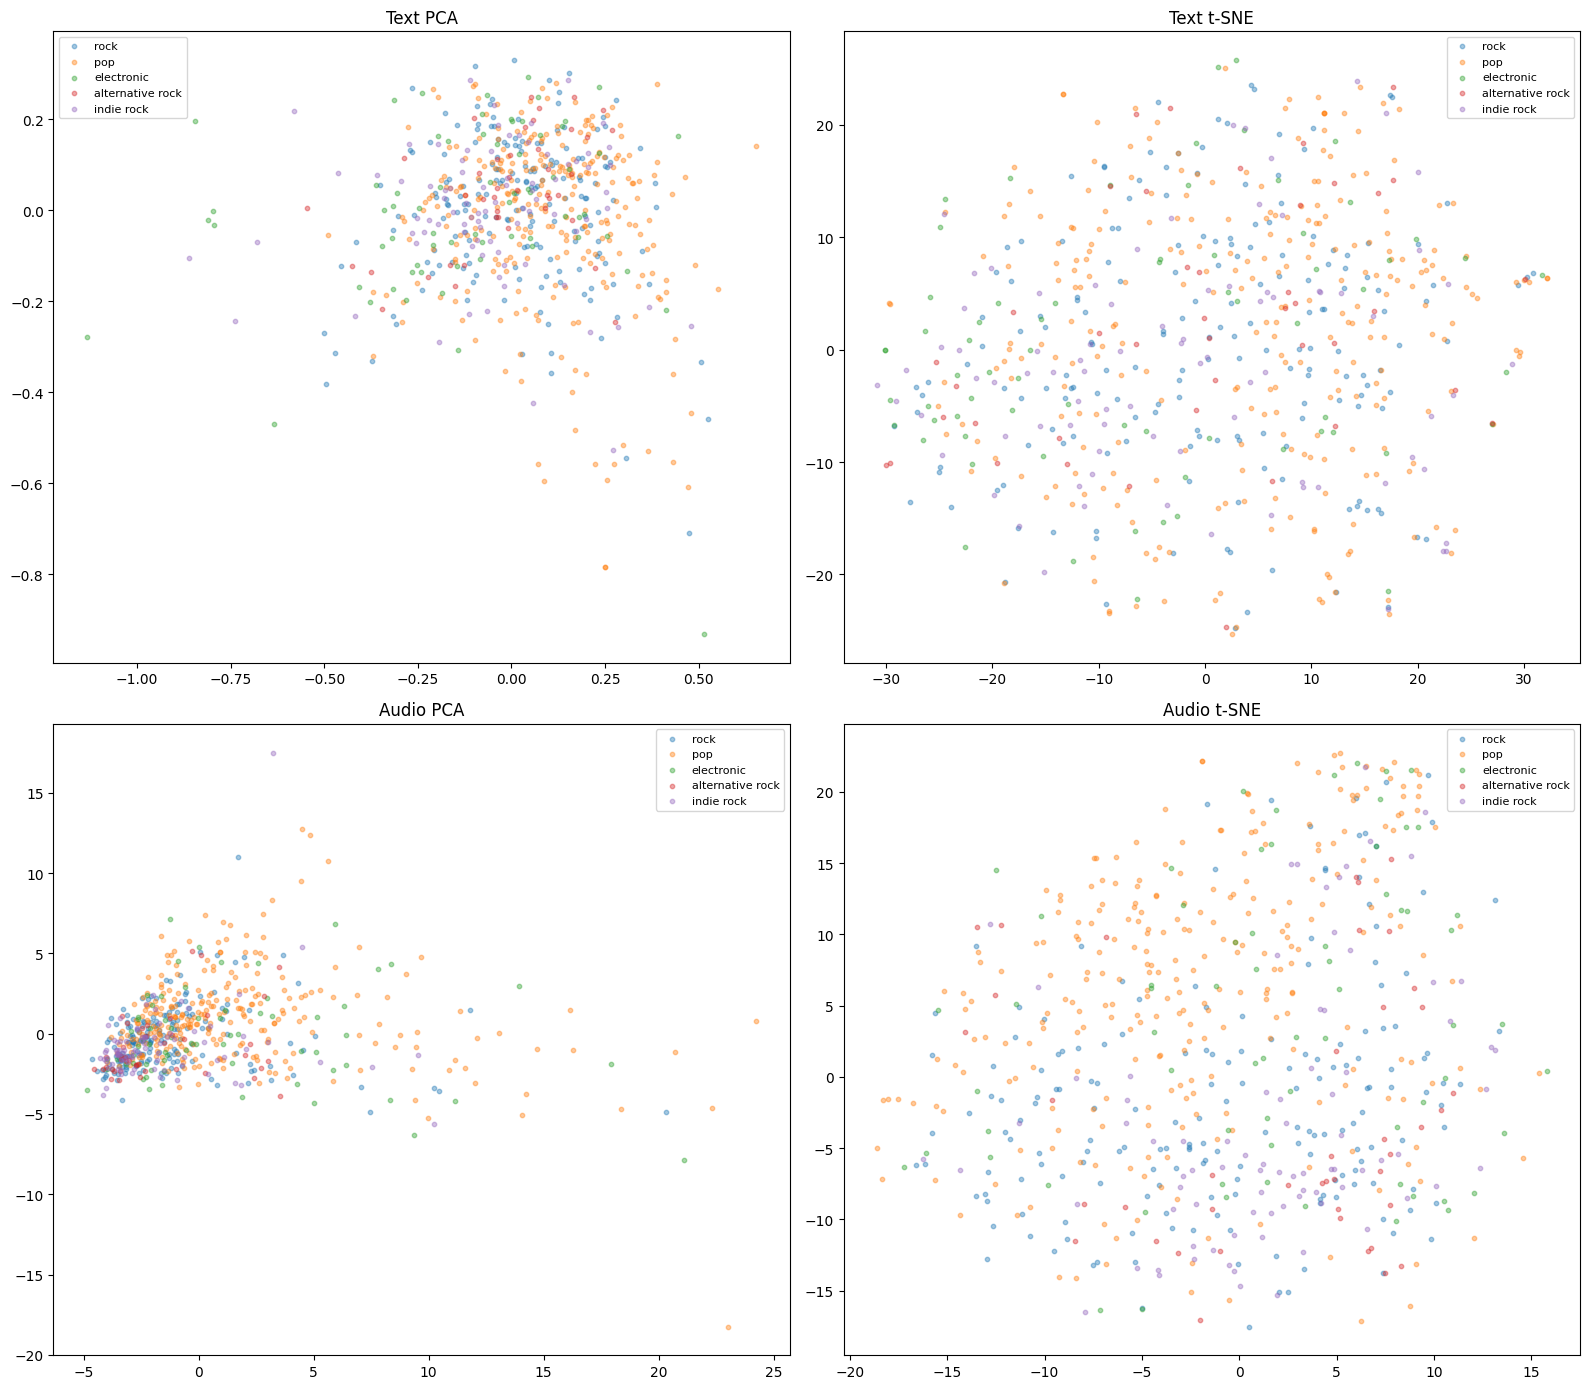

In [79]:
from sklearn.manifold import TSNE

# Assign primary genre for coloring
full['primary_genre'] = full['genres'].str.split(',').str[0].str.strip()

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Text PCA 2D
text_2d_pca = PCA(n_components=2).fit_transform(text_embeddings)
# Text t-SNE
text_2d_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(text_embeddings)
# Audio PCA 2D
audio_2d_pca = PCA(n_components=2).fit_transform(audio_embeddings)
# Audio t-SNE
audio_2d_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(audio_embeddings)

titles = ['Text PCA', 'Text t-SNE', 'Audio PCA', 'Audio t-SNE']
data = [text_2d_pca, text_2d_tsne, audio_2d_pca, audio_2d_tsne]

for ax, title, d in zip(axes.flat, titles, data):
    for genre in top5_list:
        mask = full['primary_genre'].values == genre
        ax.scatter(d[mask, 0], d[mask, 1], label=genre, alpha=0.4, s=10)
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


/tmp/ipykernel_1658/3340044109.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full['genre_count'] = full['genres'].str.split(',').apply(len)


42959    3
45978    3
18641    2
4060     3
40359    2
        ..
13139    2
52069    1
46217    1
37821    6
18391    2
Name: genre_count, Length: 1000, dtype: int64

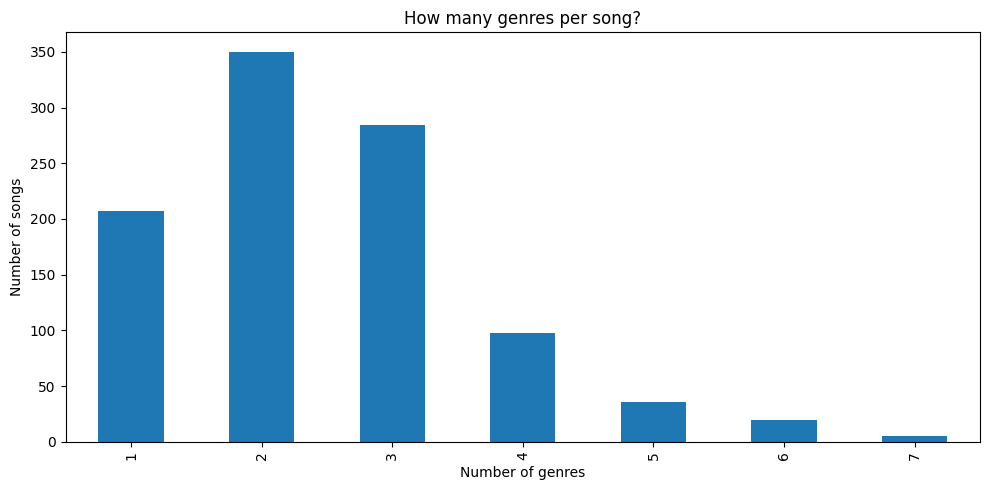

In [29]:
full['genre_count'] = full['genres'].str.split(',').apply(len)


display(full["genre_count"])

fig, ax = plt.subplots(figsize=(10, 5))
full['genre_count'].value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_xlabel('Number of genres')
ax.set_ylabel('Number of songs')
ax.set_title('How many genres per song?')
plt.tight_layout()
plt.show()


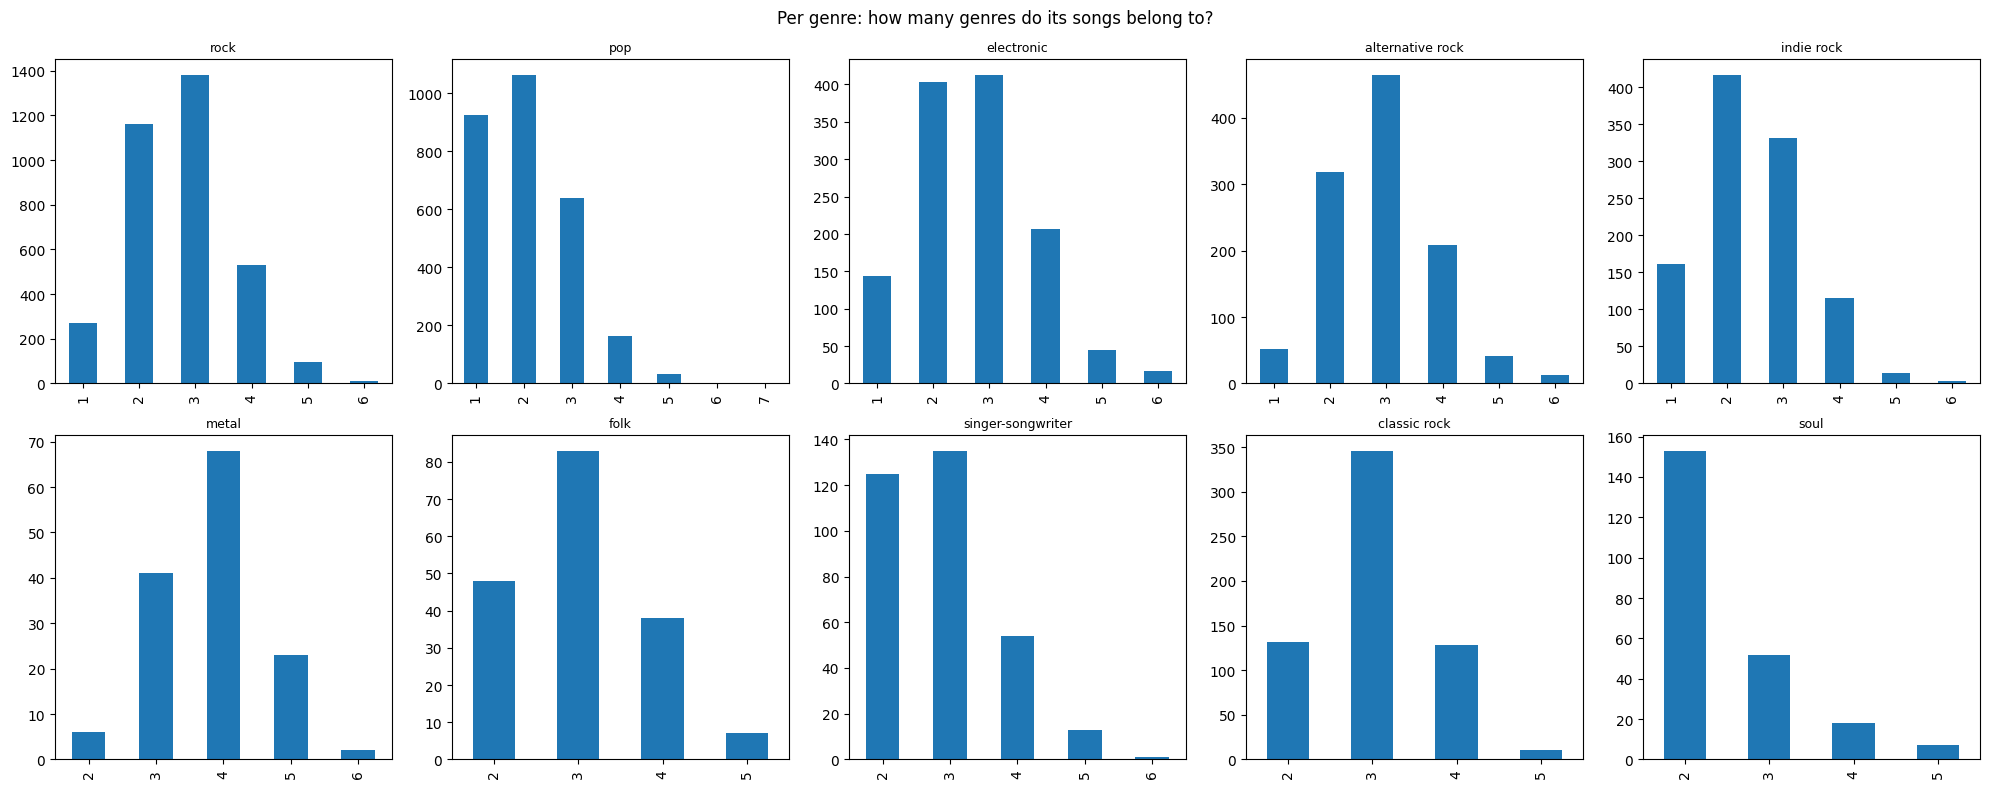

In [150]:
top10_genres = genre_exploded['genre'].value_counts().head(10).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, genre in zip(axes.flat, top10_genres):
    genre_songs = genre_exploded[genre_exploded['genre'] == genre]['id']
    counts = full[full['id'].isin(genre_songs)]['genres'].str.split(',').apply(len)
    if len(counts) > 0:
        counts.value_counts().sort_index().plot(kind='bar', ax=ax)
    ax.set_title(genre, fontsize=9)
    ax.set_xlabel('')

plt.suptitle('Per genre: how many genres do its songs belong to?')
plt.tight_layout()
plt.show()


/tmp/ipykernel_1847/1207018742.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full['word_count'] = full['lyrics'].str.split().apply(len)
/tmp/ipykernel_1847/1207018742.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full['char_count'] = full['lyrics'].str.len()
/tmp/ipykernel_1847/1207018742.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a 

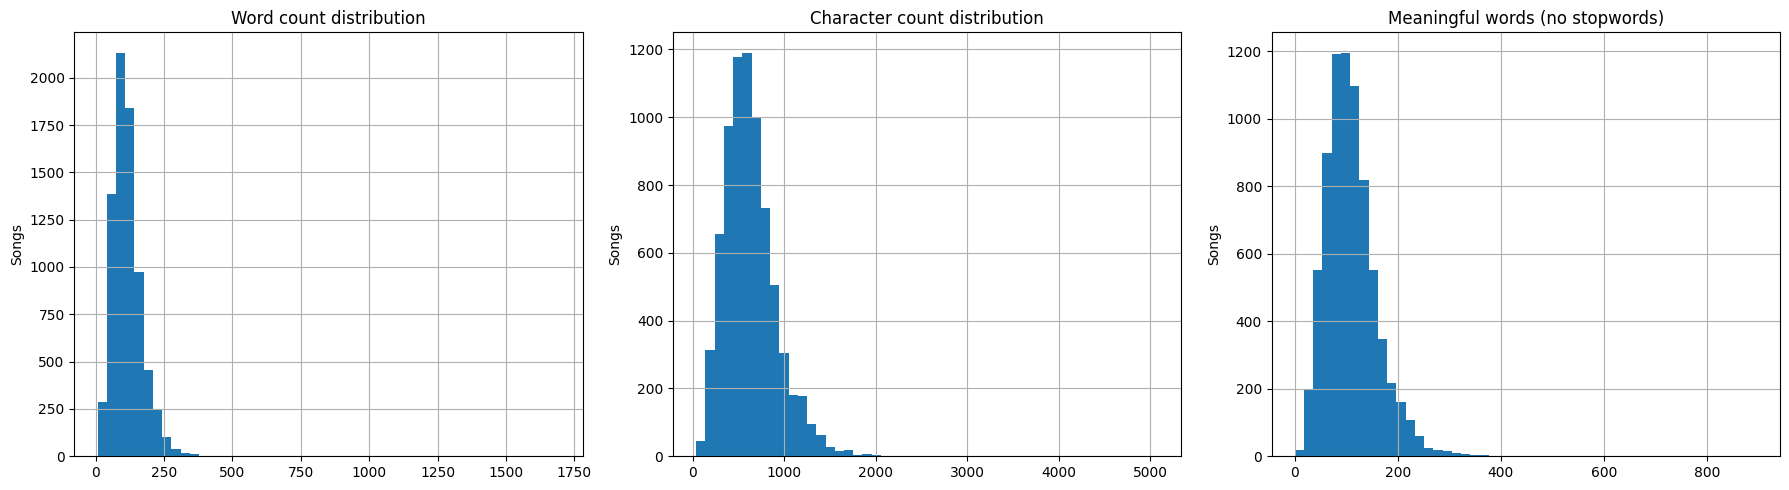

Avg words: 116, Avg meaningful: 110


In [151]:
full['word_count'] = full['lyrics'].str.split().apply(len)
full['char_count'] = full['lyrics'].str.len()
full['meaningful_words'] = full['tokens'].apply(len)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

full['word_count'].hist(bins=50, ax=axes[0])
axes[0].set_title('Word count distribution')

full['char_count'].hist(bins=50, ax=axes[1])
axes[1].set_title('Character count distribution')

full['meaningful_words'].hist(bins=50, ax=axes[2])
axes[2].set_title('Meaningful words (no stopwords)')

for ax in axes:
    ax.set_ylabel('Songs')

plt.tight_layout()
plt.show()

print(f"Avg words: {full['word_count'].mean():.0f}, Avg meaningful: {full['meaningful_words'].mean():.0f}")


In [152]:
from sklearn.metrics.pairwise import cosine_similarity

sample_idx = 0
sample = full.iloc[sample_idx]
print(f"Query: {sample['id']} | genre: {sample['genres']}\n")

# Text similarity
text_sim = cosine_similarity([text_embeddings[sample_idx]], text_embeddings)[0]
text_top5 = text_sim.argsort()[-6:-1][::-1]

print("Top 5 similar by LYRICS:")
for i in text_top5:
    r = full.iloc[i]
    print(f"  {r['id']} | {r['genres']} | sim: {text_sim[i]:.4f}")

# Audio similarity
audio_sim = cosine_similarity([audio_embeddings[sample_idx]], audio_embeddings)[0]
audio_top5 = audio_sim.argsort()[-6:-1][::-1]

print("\nTop 5 similar by AUDIO:")
for i in audio_top5:
    r = full.iloc[i]
    print(f"  {r['id']} | {r['genres']} | sim: {audio_sim[i]:.4f}")


Query: p57NIYlOER9ShCje | genre: rock,britpop,alternative rock

Top 5 similar by LYRICS:
  ZfBQquqWOihU7ykX | britpop,rock | sim: 0.9714
  VAGbVYpDCZe8KuYm | nu metal,rock,alternative rock,metal,hard rock | sim: 0.8368
  1MMLKM3p1GQwmNj3 | electronic | sim: 0.8339
  QUJ8zKT2xvrShIlP | classic rock,rock,soft rock | sim: 0.8318
  4edtfURJHArBQ9NO | progressive rock,classic rock,rock | sim: 0.8295

Top 5 similar by AUDIO:
  ZfBQquqWOihU7ykX | britpop,rock | sim: 1.0000
  HZs392QkmLezrFDR | rock | sim: 0.4081
  2ueJb7jjsNvxv9FA | rock,classic rock,pop,soft rock | sim: 0.4024
  fNHGdyMGoNWomVy5 | rock,indie rock | sim: 0.3983
  mE2cBRO5douAH96W | folk,singer-songwriter,rock,folk rock | sim: 0.3927
